In [38]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import sklearn.metrics as metrics
import math

from matplotlib import pyplot as plt
from mplsoccer import Pitch, grid

This is a quick group of functions I wrote to learn K-Means clustering of football passing, and demonstrate it on all MLS passes by right backs playing on their weak sides from 2022-2026. It should work with minimal alterations for any opta events files.

In [ ]:
left = pd.read_csv('rbs_on_left.csv')

In [3]:
def normalize_dfs(df_data:pd.DataFrame):
    
    #select only passes
    df_data = df_data[df_data['type'] == 'Pass']

    #calculate pass length (eudlidean distance)
    df_data['passlen'] = np.sqrt((df_data['endX'] - df_data['x'])**2 + (df_data['endY'] - df_data['y'])**2)

    return df_data


In [4]:
def get_elbow_graph(df_data: pd.DataFrame):
   
    K = range(1,20)
    wss= []
    for k in K:
        array = np.array(df_data[['x', 'y', 'endX', 'endY', 'passlen']])
        kmeans = KMeans(n_clusters = k, random_state = 100)
        kmeans.fit(array)
        wss_iter = kmeans.inertia_
        wss.append(wss_iter)
    
    mycenters = pd.DataFrame({'Clusters':K, 'WSS':wss})
    
    plt.scatter(x=mycenters['Clusters'], y=mycenters['WSS'])



In [5]:
def create_clusters(df_data: pd.DataFrame, n_clusters : int):
    array = np.array(df_data[['x', 'y', 'endX', 'endY', 'passlen']])
    kmeans = KMeans(n_clusters, random_state = 100)
    kmeans.fit(array)
    df_data['cluster'] = kmeans.predict(array)

    return df_data

def find_most_frequent_clusters(df_data: pd.DataFrame, n_clusters: int):
    art = df_data.cluster.value_counts().index.tolist()[0:n_clusters]

    return art


In [57]:
def plot_cluster(df_data: pd.DataFrame, cluster: int, number_plotted: int = 10, ax = None):
    
    
    
    pitch = Pitch(pitch_type='opta', axis=True, label=False)
    
    if ax is None:
        fig, ax = pitch.draw()


    df_data = df_data[df_data['cluster'] == cluster]

    for i in range(number_plotted):
                ax.annotate(
                    "",
                    xy=(df_data['endX'].iloc[i], df_data['endY'].iloc[i]),
                    xytext=(df_data['x'].iloc[i], df_data['y'].iloc[i]),
                    xycoords='data',
                    textcoords='data',
                    arrowprops=dict(
                        arrowstyle="-|>",
                        lw=1.5,
                        color='#2ecc71',
                        alpha=0.75,
                        mutation_scale=15  
                        ),
                    zorder=5
                    )
                
    ax.annotate(
            "",
            xy=(0.7, -0.02),        
            xytext=(0.3, -0.02),    
            xycoords="axes fraction",
            textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", lw=2, color="black"),
            )

                
    ax.text(
                    0.5, -0.04,              
                    "Direction of play",
                    ha="center", va="top",
                    transform=ax.transAxes,
                    fontsize=11,
                    )
                
    return pitch


In [88]:
def plot_multi_cluster(df_data: pd.DataFrame, clusters: list[int], number_plotted: int, title_text: str, total_clusters: int):

        num_grids = len(clusters)
        
        if type(num_grids/3) != int:
            num_rows = (num_grids // 3) + 1
        else:
            num_rows = num_grids / 3
        
        pitch = Pitch(pitch_type='opta', axis=True, label=False)
        fig, axs = pitch.grid(nrows=num_rows, ncols=3, figheight=30,
                      endnote_height=0.03, endnote_space=0,
                      axis=False,
                      title_height=0.08, grid_height=0.84)
        
        
        for idx, ax in enumerate(axs['pitch'].flat):
            if idx < len(clusters):
                plot_cluster(df_data, clusters[idx], number_plotted, ax=ax)
            else:
                ax.set_visible(False)  

        
        axs['title'].text(0.5, 0.65, title_text, fontsize=40,
                   va='center', ha='center')
        
        SUB_TEXT = (f'Most Prevalent {len(clusters)} Clusters out of {total_clusters}, Determined Using K-Means Clustering. {number_plotted} Passes Plotted Per Cluster.\n' 
                    f'Code Written By Nate Krackeler | github.com/nkrackeler30 | linkedin.com/in/natekrackeler | substack.com/@scnate3')
        axs['title'].text(0.5, 0.25, SUB_TEXT, fontsize=20,
                   va='center', ha='center')



            



    


In [ ]:
left = normalize_dfs(left)

/var/folders/hq/8f5kvgjd5dx23mthw16_z1lc0000gn/T/ipykernel_56354/312977082.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['passlen'] = np.sqrt((df_data['endX'] - df_data['x'])**2 + (df_data['endY'] - df_data['y'])**2)
/var/folders/hq/8f5kvgjd5dx23mthw16_z1lc0000gn/T/ipykernel_56354/312977082.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['passlen'] = np.sqrt((df_data['endX'] - df_data['x'])**2 + (df_data['endY'] - df_data['y'])**2)


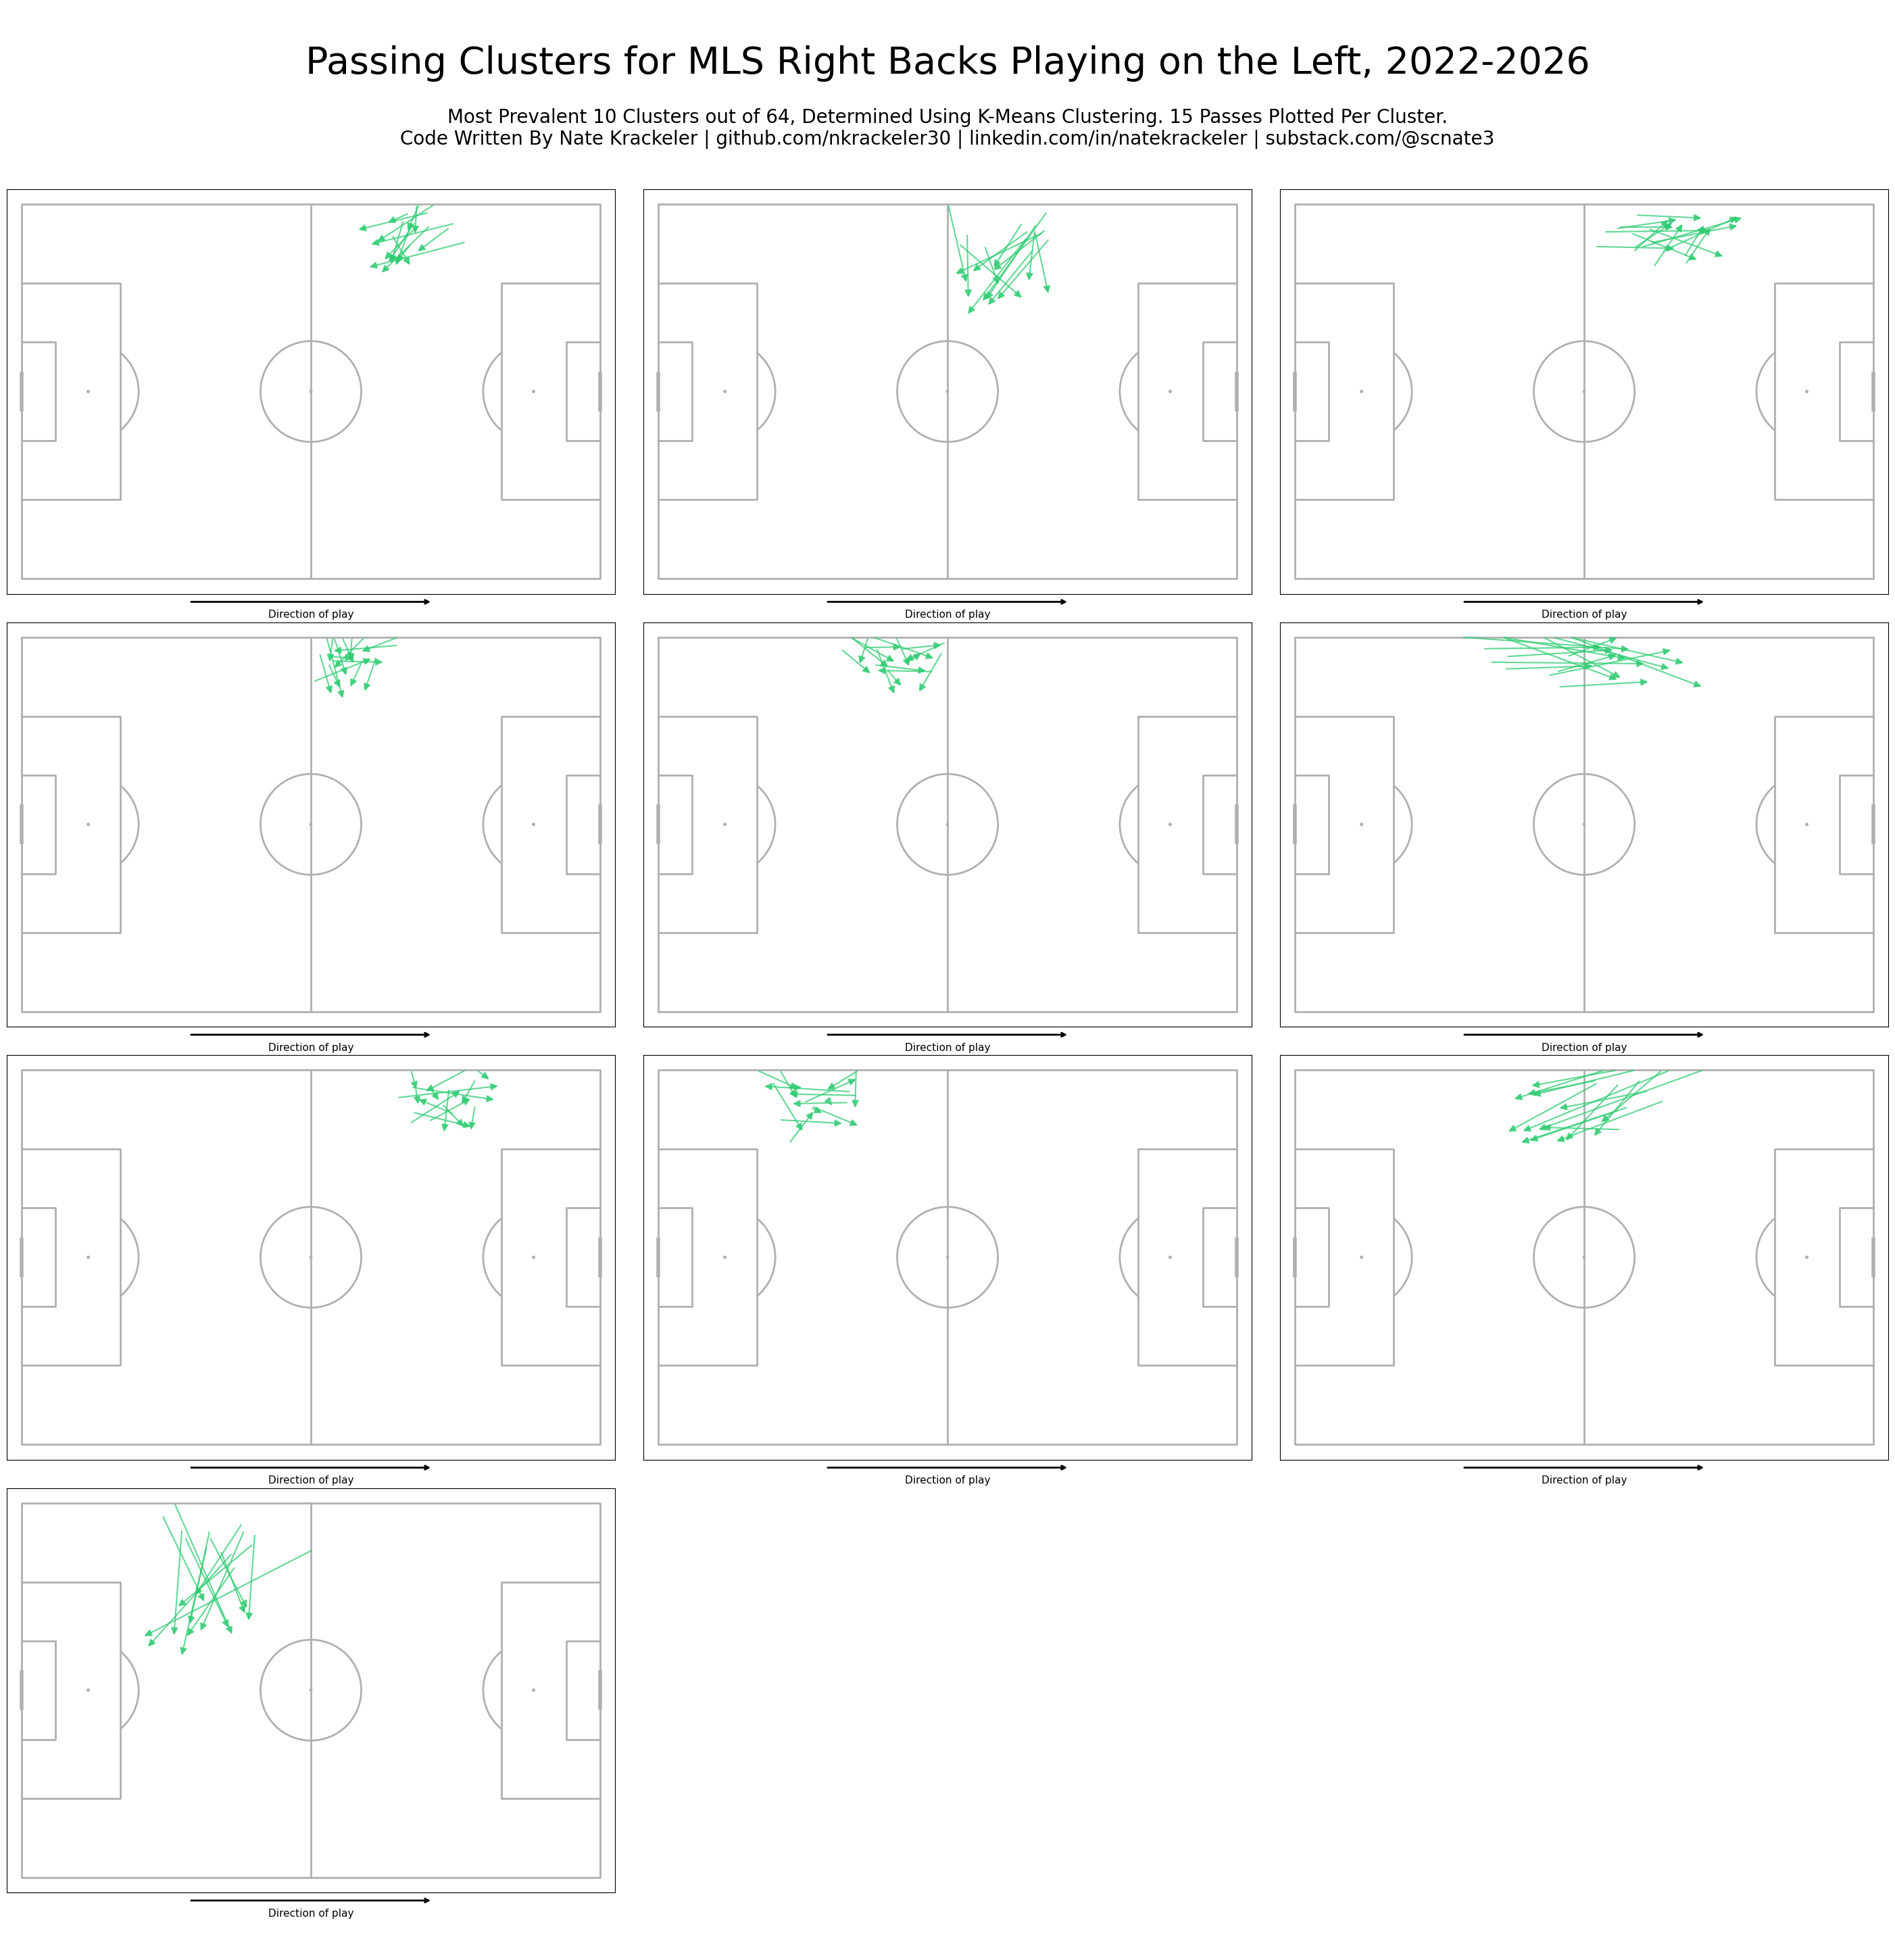

In [89]:
plot_multi_cluster(left, [9, 60, 28, 48, 40, 6, 46, 38, 24, 22], 15, 'Passing Clusters for MLS Right Backs Playing on the Left, 2022-2026', 64)